In [ ]:
# ! pip install healpy numpyro corner arviz optax reproject einops seaborn chainconsumer blackjax

In [1]:
! nvidia-smi

Sat Nov 12 23:28:17 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 515.65.01    Driver Version: 515.65.01    CUDA Version: 11.7     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-PCIE...  On   | 00000000:06:00.0 Off |                    0 |
| N/A   40C    P0    41W / 250W |      0MiB / 32768MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [2]:
import sys
import pickle
sys.path.append("../")

from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import corner
import matplotlib.pyplot as plt

from models.np_model import NPModel

%load_ext autoreload
%autoreload 2

In [3]:
r_outer = 25
l_max = 0

vary_disk = 0
vary_gamma = 1
bulge_hybrid = 1

dif = "ModelO"
ps_cat = "3fgl"
nside = 128

npmodel = NPModel(dif=dif, r_outer=r_outer, l_max=l_max, vary_disk=vary_disk, vary_gamma=vary_gamma, bulge_hybrid=bulge_hybrid, ps_cat=ps_cat, nside=nside)
# svi_results = npmodel.fit_svi(rng_key=jax.random.PRNGKey(4234), n_steps=5000)

# arviz_post = npmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(42342), num_samples=50000)
# posterior = arviz_post.to_dict()['posterior']
# posterior['logZ'] = np.array(jnp.mean(svi_results.losses[-250:]))  # Save log-evidence estimate

posterior_file = "../data/posteriors/posterior_dif_{}_r_{}_lmax_{}_vary_disk_{}_bulge_hybrid_{}_vary_gamma_{})_{}_nside_{}.p".format(dif, r_outer, l_max, vary_disk, bulge_hybrid, vary_gamma, ps_cat, nside)

# # Save data (serialize)
# with open(posterior_file, 'wb') as outfile:
#     pickle.dump(posterior, outfile, protocol=pickle.HIGHEST_PROTOCOL)

# Load data (deserialize)
with open(posterior_file, 'rb') as handle:
    posterior = pickle.load(handle)

Loading the psf correction from: /net/rcstorenfs02/ifs/rc_labs/dvorkin_lab/smsharma/mi-attribution/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


## NUTS

In [12]:
from numpyro.infer import MCMC, HMC, HMCECS, NUTS, Predictive

In [19]:
svi_results = npmodel.fit_svi(rng_key=jax.random.PRNGKey(489234), n_steps=5000)
arviz_post = npmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(42342), num_samples=5000)
posterior = arviz_post.to_dict()['posterior']
posterior.pop('logZ', None)

100%|██████████| 5000/5000 [03:56<00:00, 21.17it/s, init loss: 34393.0298, avg. loss [4751-5000]: 20082.2535]


In [20]:
inverse_mass_matrix = {}
for key in posterior.keys():
    inverse_mass_matrix[key] = jnp.var(posterior[key])

In [21]:
inverse_mass_matrix = np.cov(np.array([posterior[key] for key in posterior.keys()])[:, 0, :].T, rowvar=0)

In [22]:
from numpyro.infer.reparam import NeuTraReparam

neutra = NeuTraReparam(npmodel.guide, svi_results.params)
neutra_model = neutra.reparam(npmodel.model)

In [23]:
num_chains = 2

initial_position_batch = {}
for key in posterior.keys():
    initial_position_batch[key] = (1 + 0.1 * np.random.randn(num_chains)) * jnp.mean(posterior[key])

In [24]:
# kernel = NUTS(npmodel.model, max_tree_depth=5, dense_mass=True, inverse_mass_matrix=inverse_mass_matrix, step_size=1.)
kernel = NUTS(neutra_model, max_tree_depth=4, dense_mass=False, step_size=1.)
num_samples = 5000
mcmc = MCMC(kernel, num_warmup=200, num_samples=num_samples, num_chains=num_chains, chain_method='vectorized')
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key, data=npmodel.data, init_params=initial_position_batch)

sample: 100%|██████████| 5200/5200 [50:22<00:00,  1.72it/s]


In [25]:
mcmc.print_summary()


                            mean       std    median      5.0%     95.0%     n_eff     r_hat
 auto_shared_latent[0]     -0.21      2.21     -0.33     -3.93      3.14    549.55      1.01
 auto_shared_latent[1]     -1.19      2.32     -0.71     -4.64      2.09    241.90      1.00
 auto_shared_latent[2]     -0.70      1.82     -0.60     -3.66      2.13    365.46      1.00
 auto_shared_latent[3]      0.06      1.07      0.08     -1.61      1.83   4659.97      1.00
 auto_shared_latent[4]     -0.23      1.16     -0.23     -2.06      1.75   1588.82      1.00
 auto_shared_latent[5]     -0.04      1.77     -0.33     -2.73      2.57   1330.62      1.00
 auto_shared_latent[6]      0.04      1.33      0.15     -1.92      2.14   1018.22      1.00
 auto_shared_latent[7]     -0.69      2.74     -0.21     -4.57      2.80    356.11      1.00
 auto_shared_latent[8]      0.19      1.65      0.33     -2.30      2.93   2478.43      1.00
 auto_shared_latent[9]     -0.14      3.64     -0.33     -5.30      5

In [30]:
import arviz as az

In [28]:
zs = mcmc.get_samples(group_by_chain=True)["auto_shared_latent"]
samples = neutra.transform_sample(zs)

(array([   7.,   74.,  268.,  596.,  977., 1196., 1046.,  591.,  208.,
          37.]),
 array([0.46707413, 0.59427533, 0.72147653, 0.84867772, 0.97587892,
        1.10308012, 1.23028131, 1.35748251, 1.4846837 , 1.6118849 ,
        1.7390861 ]),
 [<matplotlib.patches.Polygon at 0x2acc54e994f0>])

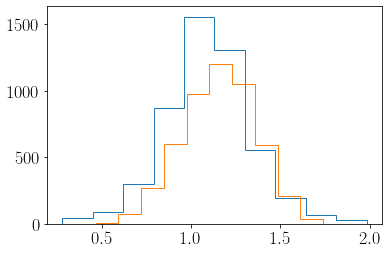

In [48]:
plt.hist(np.array(samples['gamma_ps'][0]), histtype='step')
plt.hist(np.array(posterior['gamma_ps'][0]), histtype='step')

In [43]:
az.summary(az.from_dict(samples))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
S_bub,1.090,0.082,0.932,1.241,0.001,0.001,6024.0,7367.0,1.00
S_dif,11.199,0.145,10.927,11.472,0.002,0.002,4331.0,4158.0,1.00
S_gce,1.346,0.441,0.546,1.997,0.015,0.011,733.0,751.0,1.01
S_ics,4.909,0.084,4.756,5.000,0.001,0.001,2502.0,2005.0,1.00
S_iso,0.522,0.268,0.010,0.950,0.012,0.008,412.0,225.0,1.00
S_psc,2.235,1.358,0.000,4.477,0.013,0.010,10217.0,5653.0,1.00
Sps_dsk,1.485,0.201,1.098,1.864,0.004,0.003,2226.0,1026.0,1.00
Sps_gce,0.874,0.352,0.252,1.571,0.010,0.007,1169.0,1612.0,1.00
f_bulge_poiss,0.276,0.214,0.000,0.680,0.003,0.002,3227.0,3310.0,1.00
f_bulge_ps,0.235,0.087,0.066,0.391,0.002,0.001,2264.0,4327.0,1.00


In [44]:
az.summary(az.from_dict(posterior))

Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
S_bub,1.077,0.074,0.944,1.219,0.001,0.001,4706.0,4783.0,NaN
S_dif,11.190,0.130,10.935,11.423,0.002,0.001,5145.0,4896.0,NaN
S_gce,1.474,0.231,1.051,1.861,0.003,0.002,4994.0,4475.0,NaN
S_ics,4.914,0.073,4.789,4.993,0.001,0.001,4880.0,4668.0,NaN
S_iso,0.606,0.186,0.282,0.943,0.003,0.002,4564.0,4661.0,NaN
S_psc,2.260,1.412,0.051,4.531,0.020,0.014,4827.0,4865.0,NaN
Sps_dsk,1.485,0.160,1.180,1.764,0.002,0.002,5036.0,4811.0,NaN
Sps_gce,0.662,0.184,0.338,1.002,0.003,0.002,4631.0,4984.0,NaN
f_bulge_poiss,0.217,0.144,0.021,0.493,0.002,0.001,5045.0,4982.0,NaN
f_bulge_ps,0.254,0.082,0.108,0.402,0.001,0.001,4960.0,4983.0,NaN


In [59]:
# from numpyro.contrib.nested_sampling import NestedSampler

In [58]:
# ns = NestedSampler(npmodel.model)
# ns.run(jax.random.PRNGKey(0), data=npmodel.data)

## BlackJax stuff

In [44]:
from tqdm import tqdm
from typing import Any, Callable, Iterable, Tuple, Union
from jax.experimental import host_callback

def progress_bar_scan(num_samples: int, message: Union[None, str] = None) -> Callable:
    """Decorator factory to build a tqdm progress bar using lax.scan.
    This returns a decorator to apply to the 'body' function used in lax.scan
    Args:
        num_samples (int): number of samples to run lax.scan
        message (Union[None, str]): message to display in the progress bar. Defaults to f'Running for {num_samples:,} iterations'
    Returns:
        Callable: decorator to apply to the body function used in lax.scan
    """

    if message is None:
        message = f"Running for {num_samples:,} iterations"
    tqdm_bars = {}

    def _define_tqdm(arg, transform):
        tqdm_bars[0] = tqdm(range(num_samples))
        tqdm_bars[0].set_description(message, refresh=False)

    def _update_tqdm(arg, transform):
        tqdm_bars[0].update(arg)

    def _close_tqdm(arg, transform):
        tqdm_bars[0].close()

    def _update_progress_bar(iter_num, print_rate):
        "Updates tqdm progress bar of a JAX scan or loop"
        _ = jax.lax.cond(
            iter_num == 0,
            lambda _: host_callback.id_tap(_define_tqdm, print_rate, result=iter_num),
            lambda _: iter_num,
            operand=None,
        )

        _ = jax.lax.cond(
            iter_num % print_rate == 0,
            lambda _: host_callback.id_tap(_update_tqdm, print_rate, result=iter_num),
            lambda _: iter_num,
            operand=None,
        )

        _ = jax.lax.cond(
            iter_num == num_samples - 1,
            lambda _: host_callback.id_tap(_close_tqdm, print_rate, result=iter_num),
            lambda _: iter_num,
            operand=None,
        )

    def _progress_bar_scan(func):
        """Decorator that adds a progress bar to `body_fun` used in `lax.scan`.
        Note that `body_fun` must either be looping over `np.arange(num_samples)`,
        or be looping over a tuple who's first element is `np.arange(num_samples)`
        This means that `iter_num` is the current iteration number
        """
        print_rate = int(num_samples / 20)

        def wrapper_progress_bar(carry, x):
            if type(x) is tuple:
                iter_num, *_ = x
            else:
                iter_num = x
            _update_progress_bar(iter_num, print_rate)
            return func(carry, x)

        return wrapper_progress_bar

    return _progress_bar_scan

## MEADS

In [53]:
# import blackjax
# from numpyro.infer.util import initialize_model

# rng_key = jax.random.PRNGKey(0)
# init_params, potential_fn_gen, *_ = initialize_model(
#     rng_key,
#     npmodel.model,
#     model_args=(npmodel.data,),
#     dynamic_args=True,
# )

# logprob_fn = lambda position: -potential_fn_gen(npmodel.data,)(position)

In [54]:
# [n_chain, n_warm, n_iter] = [64, 100, 100]
# ksam, kinit = jax.random.split(jax.random.PRNGKey(0), 2)

# initial_position_batch = {}
# for key in posterior.keys():
#     initial_position_batch[key] = (1 + 0.2 * np.random.randn(n_chain)) * jnp.mean(posterior[key])
    
# k_warm, k_sample = jax.random.split(ksam)
# warmup = blackjax.meads(logprob_fn, num_chain=n_chain, num_steps=n_warm, batch_fn=jax.vmap)

# chain_state, kernel, _ = warmup.run(k_warm, initial_position_batch)

# # init_state = chain_state.states


# # def one_chain(k_sam, init_state):
# #     state, info = inference_loop(k_sam, init_state, kernel, n_iter)
# #     return state.position, info


# # k_sample = jrnd.split(k_sample, n_chain)
# # samples, infos = batch_fn(one_chain)(k_sample, init_state)
# # tic2 = pd.Timestamp.now()


In [42]:
def inference_loop(rng_key, kernel, initial_state, num_samples, pbar=True):
    
    def one_step(carry, i):
        state, key = carry
        kernel_key, key = jax.random.split(key)
        state, _ = kernel(kernel_key, state)
        return (state, key), state

    lebody = progress_bar_scan(num_samples)(one_step) if pbar else one_step
    _, states = jax.lax.scan(lebody, (initial_state, rng_key), jnp.arange(num_samples))
    return states


In [43]:
import blackjax
from numpyro.infer.util import initialize_model

rng_key = jax.random.PRNGKey(0)
init_params, potential_fn_gen, *_ = initialize_model(
    rng_key,
    npmodel.model,
    model_args=(npmodel.data,),
    dynamic_args=True,
)

logprob_fn = lambda position: -potential_fn_gen(npmodel.data,)(position)

In [13]:
svi_results = npmodel.fit_svi(rng_key=jax.random.PRNGKey(4234), n_steps=1000)
arviz_post = npmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(42342), num_samples=5000)
posterior = arviz_post.to_dict()['posterior']
initial_position = {}
for key in posterior.keys():
    initial_position[key] = jnp.mean(posterior[key])

100%|██████████| 1000/1000 [03:20<00:00,  4.99it/s, init loss: 26055.4020, avg. loss [951-1000]: 20092.8584]


In [ ]:
num_warmup = 200

adapt = blackjax.window_adaptation(
    blackjax.nuts, logprob_fn, num_warmup, target_acceptance_rate=0.8, progress_bar=True
)

last_state, kernel, _ = adapt.run(rng_key, initial_position)

Running window adaptation


In [ ]:
num_sample = 1000

states = inference_loop(rng_key, kernel, last_state, num_sample)

  0%|          | 0/1000 [00:00<?, ?it/s]

## MALA

In [7]:
npmodel = NPModel(dif=dif, r_outer=r_outer, l_max=l_max, vary_disk=False, vary_gamma=False, bulge_hybrid=False, ps_cat=ps_cat, nside=nside)

Loading the psf correction from: /net/rcstorenfs02/ifs/rc_labs/dvorkin_lab/smsharma/mi-attribution/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [8]:
import blackjax
from numpyro.infer.util import initialize_model

rng_key = jax.random.PRNGKey(0)

init_params, potential_fn_gen, *_ = initialize_model(
    rng_key,
    npmodel.model,
    model_args=(npmodel.data,),
    dynamic_args=True,
)

logprob_fn = lambda position: -potential_fn_gen(npmodel.data,)(position)

In [23]:
initial_position_batch = {}
for key in posterior.keys():
    initial_position_batch[key] = jnp.ones(1) * jnp.mean(posterior[key])

In [24]:
for key in ['C', 'zs', 'gamma_poiss', 'gamma_ps', 'f_bulge_ps', 'f_bulge_poiss']:
    initial_position_batch.pop(key, None)

In [25]:
logprob_fn_vmap = jax.vmap(logprob_fn)

In [26]:
# logprob_fn_vmap(initial_position_batch)

In [27]:
warmup = blackjax.meads(logprob_fn, num_chain=1, num_steps=10)
last_states, kernel, _ = warmup.run(
            jax.random.PRNGKey(0),
            initial_position_batch,
        )

ValueError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 1572864 bytes.
BufferAssignment OOM Debugging.
BufferAssignment stats:
             parameter allocation:    3.00MiB
              constant allocation:         0B
        maybe_live_out allocation:    1.50MiB
     preallocated temp allocation:         0B
                 total allocation:    4.50MiB
              total fragmentation:         0B (0.00%)
Peak buffers:
	Buffer 1:
		Size: 1.50MiB
		Entry Parameter Subshape: f64[196608]
		==========================

	Buffer 2:
		Size: 1.50MiB
		Entry Parameter Subshape: f64[196608]
		==========================

	Buffer 3:
		Size: 1.50MiB
		Operator: op_name="jit(fn)/jit(main)/mul" source_file="../models/np_model.py" source_line=139
		XLA Label: multiply
		Shape: f64[196608]
		==========================

